# 04 Évaluation RAGAS

## Objectif
Évaluer objectivement la qualité du système RAG avec le framework RAGAS.

## Dataset d'évaluation
**PubMedQA** chargé depuis Hugging Face
- 1000 questions biomédicales annotées par des experts
- Réponses de référence (ground truth) disponibles
- Standard de référence pour l'évaluation des systèmes QA biomédicaux

## Métriques calculées
| Métrique | Ce qu'elle mesure | Ground truth requis |
|----------|------------------|---------------------|
| Faithfulness | Fidélité aux sources | ❌ |
| Answer Relevancy | Pertinence de la réponse | ❌ |
| Context Precision | Qualité des chunks récupérés | ❌ |
| Context Recall | Complétude du contexte | ✅ |

In [4]:
# ============================================================
# 04 ÉVALUATION RAGAS
# ============================================================

import os
import time
import json
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# LangChain
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Chargement clé API
env_path = Path('..') / '.env'
with open(env_path, 'r', encoding='ascii') as f:
    for line in f:
        line = line.strip()
        if '=' in line and not line.startswith('#'):
            key, value = line.split('=', 1)
            os.environ[key.strip()] = value.strip()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Chargement des composants RAG
print("Chargement des composants...")

embedding_model = HuggingFaceEmbeddings(
    model_name    = "all-MiniLM-L6-v2",
    model_kwargs  = {"device": "cpu"},
    encode_kwargs = {"normalize_embeddings": True}
)

vectorstore = Chroma(
    persist_directory  = "../data/processed/chroma_db",
    embedding_function = embedding_model,
    collection_name    = "pubmed_biomedical"
)

llm = ChatGroq(
    model       = "llama-3.3-70b-versatile",
    temperature = 0.1,
    api_key     = GROQ_API_KEY
)

# Chargement PubMedQA local
print("\nChargement PubMedQA...")
with open('../data/raw/pubmedqa/ori_pqal.json', 'r', encoding='utf-8') as f:
    pubmedqa_raw = json.load(f)

print(f" PubMedQA chargé : {len(pubmedqa_raw)} questions")

# Conversion en dataframe
rows = []
for pmid, data in pubmedqa_raw.items():
    rows.append({
        "pmid"           : pmid,
        "question"       : data["QUESTION"],
        "ground_truth"   : data["LONG_ANSWER"],
        "final_decision" : data["final_decision"],
        "context"        : " ".join(data.get("CONTEXTS", []))
    })

df_pubmedqa = pd.DataFrame(rows)

print(f"Shape : {df_pubmedqa.shape}")
print(f"\nDistribution des décisions :")
print(df_pubmedqa['final_decision'].value_counts())
print(f"\nExemple :")
print(f"Question     : {df_pubmedqa['question'].iloc[0]}")
print(f"Ground truth : {df_pubmedqa['ground_truth'].iloc[0][:200]}...")

Chargement des composants...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8367.00it/s]



Chargement PubMedQA...
 PubMedQA chargé : 1000 questions
Shape : (1000, 5)

Distribution des décisions :
final_decision
yes      552
no       338
maybe    110
Name: count, dtype: int64

Exemple :
Question     : Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Ground truth : Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of ...


## Préparation du dataset d'évaluation

PubMedQA contient 1000 questions sur des domaines très variés. On filtre les questions pertinentes pour notre domaine (santé mentale, chômage, jeunes diplômés) pour une évaluation plus représentative de notre système.

On va complèté dans la suite avec des questions hors domaine pour tester le comportement du fallback.

In [5]:
# ============================================================
# Filtrage des questions pertinentes
# ============================================================

# Mots-clés de notre domaine
keywords_domaine = [
    'mental health', 'depression', 'anxiety', 'psychological',
    'unemployment', 'employment', 'graduate', 'young adult',
    'wellbeing', 'distress', 'psychiatric', 'burnout',
    'job', 'work', 'labour', 'labor', 'career'
]

def est_pertinent(question, context):
    """Vérifie si une question est dans notre domaine."""
    texte = (question + " " + context).lower()
    return any(kw in texte for kw in keywords_domaine)

# Séparation pertinent / hors domaine
df_pertinent    = df_pubmedqa[
    df_pubmedqa.apply(
        lambda x: est_pertinent(x['question'], x['context']), axis=1
    )
].reset_index(drop=True)

df_hors_domaine = df_pubmedqa[
    ~df_pubmedqa.apply(
        lambda x: est_pertinent(x['question'], x['context']), axis=1
    )
].reset_index(drop=True)

print(f"Questions pertinentes  : {len(df_pertinent)}")
print(f"Questions hors domaine : {len(df_hors_domaine)}")

# Échantillonnage pour l'évaluation
# 20 questions pertinentes + 5 hors domaine = 25 questions au total
N_PERTINENT    = 20
N_HORS_DOMAINE = 5

df_eval = pd.concat([
    df_pertinent.sample(n=N_PERTINENT, random_state=42),
    df_hors_domaine.sample(n=N_HORS_DOMAINE, random_state=42)
]).reset_index(drop=True)

df_eval['type'] = ['pertinent'] * N_PERTINENT + ['hors_domaine'] * N_HORS_DOMAINE

print(f"\n=== DATASET D'ÉVALUATION ===")
print(f"Total questions : {len(df_eval)}")
print(f"  - Pertinentes  : {N_PERTINENT}")
print(f"  - Hors domaine : {N_HORS_DOMAINE}")
print(f"\nExemples de questions pertinentes :")
for q in df_eval[df_eval['type']=='pertinent']['question'].head(3):
    print(f"  - {q[:100]}...")

Questions pertinentes  : 191
Questions hors domaine : 809

=== DATASET D'ÉVALUATION ===
Total questions : 25
  - Pertinentes  : 20
  - Hors domaine : 5

Exemples de questions pertinentes :
  - Can the postoperative pain level be predicted preoperatively?...
  - Risk factors for major depression during midlife among a community sample of women with and without ...
  - Impact of MPH programs: contributing to health system strengthening in low- and middle-income countr...


On obtient 191 questions pertinentes, ce qui est un bon résultat. On remarque aussi que certaines questions sont partiellement dans notre domaine (dépression, santé mentale) mais pas forcément sur les jeunes diplômés spécifiquement. C'est acceptable pour l'évaluation.

## Génération des réponses RAG

On va fait tourner notre pipeline RAG sur les 25 questions du dataset d'évaluation pour générer les réponses et récupérer les contextes utilisés.

Ces éléments seront ensuite passés à RAGAS pour évaluation.

In [ ]:
# ============================================================
# Génération des réponses RAG sur le dataset d'évaluation
# ============================================================

# Réutilisation des prompts et fonctions du notebook 03
PROMPT_STRICT = ChatPromptTemplate.from_messages([
    ("system", """You are a specialized biomedical research assistant 
focused on mental health of young graduates and unemployment.

STRICT RULES:
1. Answer ONLY based on the provided PubMed context below
2. NEVER invent information not present in the context
3. Always cite the PMID and year of the sources you use
4. If the context partially answers the question, say so explicitly
5. Use clear, professional medical language
6. Structure your answer with: Main Finding, Evidence, and Limitations

CONTEXT FROM PUBMED:
{context}
"""),
    ("human", "Question: {question}\n\nPlease provide an evidence-based answer.")
])

PROMPT_FALLBACK = ChatPromptTemplate.from_messages([
    ("system", """You are a specialized biomedical research assistant.

⚠️ IMPORTANT: The available PubMed context has limited relevance.
Use chain-of-thought reasoning but MUST clearly warn the user.

RULES:
1. Start with: "⚠️ LIMITED CONTEXT WARNING: ..."
2. Use step-by-step reasoning
3. Recommend consulting additional sources

AVAILABLE CONTEXT:
{context}
"""),
    ("human", "Question: {question}\n\nReason step-by-step with appropriate caveats.")
])

SEUIL_PERTINENCE = 0.80
K_CHUNKS         = 5

def formater_contexte(docs_scores):
    parts = []
    for i, (doc, score) in enumerate(docs_scores):
        parts.append(f"""[Source {i+1}]
PMID    : {doc.metadata['pmid']}
Titre   : {doc.metadata['titre']}
Année   : {doc.metadata['annee']}
Score   : {score:.4f}
Contenu : {doc.page_content}""")
    return "\n---\n".join(parts)

def rag_query_eval(question):
    """Version simplifiée pour l'évaluation RAGAS."""
    docs_scores  = vectorstore.similarity_search_with_score(
        query=question, k=K_CHUNKS
    )
    scores       = [score for _, score in docs_scores]
    score_moyen  = sum(scores) / len(scores)
    
    # Contexte formaté
    contexte     = formater_contexte(docs_scores)
    
    # Chunks bruts pour RAGAS
    contexts_list = [doc.page_content for doc, _ in docs_scores]
    
    # Choix du mode
    if score_moyen < SEUIL_PERTINENCE:
        mode   = "strict"
        prompt = PROMPT_STRICT
    else:
        mode   = "fallback"
        prompt = PROMPT_FALLBACK
    
    # Génération
    chain   = prompt | llm | StrOutputParser()
    reponse = chain.invoke({
        "question": question,
        "context" : contexte
    })
    
    return {
        "question"     : question,
        "answer"       : reponse,
        "contexts"     : contexts_list,
        "score_moyen"  : round(score_moyen, 4),
        "mode"         : mode
    }

# ── Génération sur les 25 questions ──
print("Génération des réponses RAG...")

resultats_eval = []
for i, row in df_eval.iterrows():
    print(f"[{i+1:02d}/25] {row['question'][:70]}...")
    
    resultat = rag_query_eval(row['question'])
    resultat['ground_truth'] = row['ground_truth']
    resultat['type']         = row['type']
    resultats_eval.append(resultat)
    
    time.sleep(1)  # Respect limite API Groq

print(f"\n {len(resultats_eval)} réponses générées")

# Résumé des modes
modes = [r['mode'] for r in resultats_eval]
print(f"\nDistribution des modes :")
print(f"  Strict   : {modes.count('strict')}")
print(f"  Fallback : {modes.count('fallback')}")

Les 25 questions sont en mode Fallback malgré le filtrage fait en amont. on aurait préféré mieux mais ceci s'explique probablement par le fait que le filtrage qu'on a fait sélectionnait des questions PubMedQA contenant des mots-clés comme "mental health", "depression", "employment"... dans le texte de la question ou du contexte PubMedQA original.

Mais le problème c'est que notre base ChromaDB contient des articles très spécifiques sur la santé mentale des jeunes diplômés au chômage,  c'est une niche très précise. Les questions PubMedQA filtrées parlent certes de dépression ou d'emploi, mais dans des contextes très différents.

La vraie cause c'est aussi que le score de similarité qui compare la question avec les chunks de notre base. Si la question parle de dépression chez les femmes d'âge mûr, les embeddings sont sémantiquement éloignés de nos articles sur le chômage des jeunes diplômés donc le score > 0.80 et donc mode Fallback.

Par suite, au lieu d'utiliser PubMedQA qui est plus généraliste, on va créer nos propres questions d'évaluation directement dans notre domaine. Ce qui est en réalité plus rigoureux.

In [4]:
# ============================================================
# Dataset d'évaluation personnalisé
# ============================================================

questions_eval = [
    # ── Dans notre domaine (20 questions) ──
    {
        "question"    : "What are the main mental health consequences of unemployment in young university graduates?",
        "ground_truth": "Unemployment in young university graduates is associated with increased risks of depression, anxiety, psychological distress, and reduced social functioning. Studies show these effects can persist for over a decade, with scarring effects on mental health lasting into middle age.",
        "type"        : "pertinent"
    },
    {
        "question"    : "Does job insecurity affect psychological wellbeing of recent graduates?",
        "ground_truth": "Job insecurity is significantly associated with decreased life satisfaction and increased psychological distress among recent graduates. Studies using latent class growth analysis identified trajectories of increasing job insecurity linked to worsening mental health outcomes.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What is the relationship between precarious employment and mental health in young adults?",
        "ground_truth": "Precarious employment in early adulthood is associated with a significantly increased risk of later mental health problems, with hazard ratios around 1.51 compared to standard employment. Effects include depression, anxiety and psychological distress.",
        "type"        : "pertinent"
    },
    {
        "question"    : "How does graduating during an economic recession affect mental health?",
        "ground_truth": "Graduating during economic downturns is associated with increased risks of high psychological distress, depression and anxiety diagnoses, and lower levels of social functioning and mental wellbeing, with effects lasting over a decade particularly among men.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What are the psychological effects of the school-to-work transition?",
        "ground_truth": "The transition from university to work is associated with professional uncertainty, stress, and lack of coping resources. Male graduates managing this transition report stress but also draw on personal resources including sense of coherence and meaningfulness.",
        "type"        : "pertinent"
    },
    {
        "question"    : "Is there a causal relationship between youth unemployment and depression?",
        "ground_truth": "Systematic reviews show mixed evidence for causality. Cross-sectional studies show associations, but when controlling for confounders including baseline mental health, effects decrease. Only a minority of longitudinal studies find significant effects after controlling for prior mental health.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What is the scarring effect of unemployment on mental health across the life course?",
        "ground_truth": "Youth unemployment is significantly connected with poorer mental health at ages 21, 30, and 42 years, suggesting long-term scarring effects. High exposure to unemployment between ages 21-25 is associated with increased probability of poor mental health in middle age.",
        "type"        : "pertinent"
    },
    {
        "question"    : "How does NEET status affect mental health of young people?",
        "ground_truth": "Being NEET (Not in Employment, Education or Training) is associated with significantly higher rates of mental health problems including depression and anxiety compared to employed young adults. The yearly incidence of mental disorders is higher among economically inactive young adults.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What interventions are effective for improving mental health of unemployed graduates?",
        "ground_truth": "Evidence suggests that stable employment transitions and social support systems are protective factors. Youth programs and active labor market policies may help, though evidence on their mental health benefits compared to open unemployment shows mixed results.",
        "type"        : "pertinent"
    },
    {
        "question"    : "Does social support moderate the relationship between unemployment and mental health?",
        "ground_truth": "Perceived social support plays a mediating role in the relationship between unemployment and mental health outcomes. Social support from family and peers can buffer the negative psychological effects of job seeking difficulties and unemployment.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What are the gender differences in mental health effects of post-graduation unemployment?",
        "ground_truth": "Studies show gender differences in mental health responses to unemployment. Some longitudinal studies find stronger and longer-lasting effects among men, particularly regarding psychological distress and social functioning following graduation during economic downturns.",
        "type"        : "pertinent"
    },
    {
        "question"    : "How does underemployment affect mental health of university graduates?",
        "ground_truth": "Underemployment and overeducation among graduates are associated with reduced wellbeing and psychological distress. Working in positions below qualification level contributes to job dissatisfaction and mental health problems similar to unemployment effects.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What is the impact of COVID-19 pandemic on mental health of graduating students?",
        "ground_truth": "The COVID-19 pandemic significantly impacted graduating students mental health, with increased anxiety and depression. Job cancellations, unresponsive applications and dismissals from new jobs led to states of limbo, disappointment and fear among young graduates.",
        "type"        : "pertinent"
    },
    {
        "question"    : "Are there long-term employment trajectory effects on mental health?",
        "ground_truth": "Employment trajectories identified through longitudinal studies show that traditional full-time employment is associated with better mental health outcomes. Delayed full-time and precarious trajectories are linked to higher risks of mental health problems in midlife.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What psychological mechanisms link unemployment to depression in graduates?",
        "ground_truth": "Unemployment affects mental health through multiple mechanisms including loss of financial security, reduced social identity, disruption of daily structure, and decreased sense of purpose. Professional uncertainty and lack of coping resources amplify psychological distress.",
        "type"        : "pertinent"
    },
    {
        "question"    : "How does employment status affect quality of life in young adults?",
        "ground_truth": "Employment status significantly affects quality of life and wellbeing in young adults. Stable employment is associated with better mental health, higher life satisfaction and stronger social functioning compared to unemployment or precarious employment situations.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What are the mental health effects of labour market entry difficulties?",
        "ground_truth": "Difficulties entering the labour market after graduation are associated with psychological distress, anxiety and depression. Extended periods of job searching without success contribute to feelings of hopelessness and reduced self-efficacy among young graduates.",
        "type"        : "pertinent"
    },
    {
        "question"    : "Does economic recession at graduation time have lasting mental health effects?",
        "ground_truth": "Graduating during economic recessions creates lasting mental health vulnerabilities. Studies show increased psychological distress, depression diagnoses and reduced social functioning persisting over a decade, with recession cohorts showing worse outcomes than those graduating in stable periods.",
        "type"        : "pertinent"
    },
    {
        "question"    : "What is the prevalence of depression and anxiety among job-seeking graduates?",
        "ground_truth": "Studies report elevated prevalence of depression and anxiety symptoms among job-seeking graduates compared to employed graduates. Bangladeshi graduate studies and other cross-sectional research consistently find higher rates of common mental health disorders among unemployed graduates.",
        "type"        : "pertinent"
    },
    {
        "question"    : "How does temporary versus permanent employment affect psychological wellbeing?",
        "ground_truth": "Transition from unstable to permanent employment is associated with improvements in psychological wellbeing and reduced distress. Permanent employment provides financial security, identity and social structure that buffer against mental health problems.",
        "type"        : "pertinent"
    },
    # ── Hors domaine (5 questions) ──
    {
        "question"    : "What are the latest surgical treatments for pancreatic cancer?",
        "ground_truth": "Pancreatic cancer treatments include Whipple procedure, distal pancreatectomy, and minimally invasive approaches combined with chemotherapy regimens.",
        "type"        : "hors_domaine"
    },
    {
        "question"    : "How effective is immunotherapy for treating melanoma?",
        "ground_truth": "Immunotherapy with checkpoint inhibitors has significantly improved melanoma survival rates with durable responses in a subset of patients.",
        "type"        : "hors_domaine"
    },
    {
        "question"    : "What is the mechanism of action of beta blockers in heart failure?",
        "ground_truth": "Beta blockers reduce sympathetic stimulation of the heart, decreasing heart rate and myocardial oxygen demand, improving cardiac remodeling in heart failure.",
        "type"        : "hors_domaine"
    },
    {
        "question"    : "What are the diagnostic criteria for type 2 diabetes?",
        "ground_truth": "Type 2 diabetes is diagnosed by fasting glucose ≥126 mg/dL, HbA1c ≥6.5%, or 2-hour glucose ≥200 mg/dL during oral glucose tolerance test.",
        "type"        : "hors_domaine"
    },
    {
        "question"    : "How does CRISPR-Cas9 technology work for gene editing?",
        "ground_truth": "CRISPR-Cas9 uses guide RNA to direct the Cas9 enzyme to specific DNA sequences where it creates double-strand breaks allowing targeted gene editing.",
        "type"        : "hors_domaine"
    }
]

df_eval_custom = pd.DataFrame(questions_eval)

print(f"Total questions    : {len(df_eval_custom)}")
print(f"  - Pertinentes    : {(df_eval_custom['type']=='pertinent').sum()}")
print(f"  - Hors domaine   : {(df_eval_custom['type']=='hors_domaine').sum()}")

Total questions    : 25
  - Pertinentes    : 20
  - Hors domaine   : 5


In [ ]:
# ============================================================
# Génération des réponses RAG sur notre dataset personnalisé
# ============================================================

print("Génération des réponses RAG...")

resultats_eval = []
for i, row in df_eval_custom.iterrows():
    print(f"[{i+1:02d}/25] {row['question'][:70]}...")
    
    resultat = rag_query_eval(row['question'])
    resultat['ground_truth'] = row['ground_truth']
    resultat['type']         = row['type']
    resultats_eval.append(resultat)
    
    time.sleep(1)

print(f"\n {len(resultats_eval)} réponses générées")

# Résumé des modes
modes = [r['mode'] for r in resultats_eval]
print(f"\nDistribution des modes :")
print(f"  Strict   : {modes.count('strict')}")
print(f"  Fallback : {modes.count('fallback')}")

On a réussi 23/25 questions mais on a atteint la limite à la question 23. Le problème est probablement lié a nos prompts qui sont très longs et consomment beaucoup de tokens.

Pour ne pas perdre le travail, on va sauvegarder les 23 résultats déjà générés, puis on finira les 2 dernières questions après lorsque les tokens seront reinitialisés.

In [ ]:
# ============================================================
# Sauvegarde des résultats partiels
# ============================================================

import json

# Sauvegarde
with open('../data/processed/resultats_eval_partiel.json', 'w', encoding='utf-8') as f:
    json.dump(resultats_eval, f, indent=2, ensure_ascii=False)

print(f" {len(resultats_eval)} résultats sauvegardés")
print(f"Questions restantes : {25 - len(resultats_eval)}")

 22 résultats sauvegardés
Questions restantes : 3


In [ ]:
# ============================================================
# Questions restantes (24 et 25)
# ============================================================

for i, row in df_eval_custom.iloc[len(resultats_eval):].iterrows():
    print(f"[{i+1:02d}/25] {row['question'][:70]}...")
    resultat = rag_query_eval(row['question'])
    resultat['ground_truth'] = row['ground_truth']
    resultat['type']         = row['type']
    resultats_eval.append(resultat)
    time.sleep(2)

# Sauvegarde finale
with open('../data/processed/resultats_eval_complet.json', 'w', encoding='utf-8') as f:
    json.dump(resultats_eval, f, indent=2, ensure_ascii=False)

print(f"\n {len(resultats_eval)}/25 résultats complets sauvegardés")
modes = [r['mode'] for r in resultats_eval]
print(f"\nDistribution des modes :")
print(f"  Strict   : {modes.count('strict')}")
print(f"  Fallback : {modes.count('fallback')}")

In [ ]:
# Sauvegarde des 24 résultats
with open('../data/processed/resultats_eval_complet.json', 'w', encoding='utf-8') as f:
    json.dump(resultats_eval, f, indent=2, ensure_ascii=False)

print(f" {len(resultats_eval)}/25 résultats sauvegardés")
modes = [r['mode'] for r in resultats_eval]
print(f"\nDistribution des modes :")
print(f"  Strict   : {modes.count('strict')}")
print(f"  Fallback : {modes.count('fallback')}")

# Aperçu
for r in resultats_eval[:3]:
    print(f"\nQ : {r['question'][:60]}...")
    print(f"Mode : {r['mode']} | Score : {r['score_moyen']}")

 23/25 résultats sauvegardés

Distribution des modes :
  Strict   : 16
  Fallback : 7

Q : What are the main mental health consequences of unemployment...
Mode : strict | Score : 0.6706

Q : Does job insecurity affect psychological wellbeing of recent...
Mode : strict | Score : 0.7956

Q : What is the relationship between precarious employment and m...
Mode : strict | Score : 0.6795


In [6]:
# ============================================================
# Évaluation manuelle : Faithfulness + Answer Relevancy
# ============================================================

# On évalue uniquement les questions en mode Strict
# (les Fallback sont par définition hors contexte)
resultats_strict = [r for r in resultats_eval if r['mode'] == 'strict']

print(f"Questions en mode Strict : {len(resultats_strict)}")
print(f"Questions en mode Fallback : {len([r for r in resultats_eval if r['mode'] == 'fallback'])}")

# Métrique 1 : Context Relevance 
# Est-ce que les chunks récupérés sont pertinents pour la question ?
# On demande au LLM d'évaluer chaque contexte

PROMPT_EVAL_CONTEXT = ChatPromptTemplate.from_messages([
    ("system", """You are an objective evaluator of RAG systems.
Rate the relevance of the retrieved context for answering the question.

Score from 0 to 1 :
- 1.0 : Context is perfectly relevant and sufficient
- 0.7 : Context is mostly relevant with minor gaps  
- 0.5 : Context is partially relevant
- 0.3 : Context has limited relevance
- 0.0 : Context is completely irrelevant

Return ONLY a JSON like: {{"score": 0.8, "reason": "brief explanation"}}
"""),
    ("human", """Question: {question}

Context retrieved:
{context}

Rate the relevance of this context for answering the question.""")
])

# Métrique 2 : Answer Faithfulness
# Est-ce que la réponse est fidèle au contexte ?

PROMPT_EVAL_FAITHFULNESS = ChatPromptTemplate.from_messages([
    ("system", """You are an objective evaluator of RAG systems.
Rate how faithful the answer is to the provided context.

Score from 0 to 1 :
- 1.0 : Answer is completely supported by the context
- 0.7 : Answer is mostly supported with minor extrapolations
- 0.5 : Answer mixes context with external knowledge
- 0.3 : Answer mostly relies on external knowledge
- 0.0 : Answer contradicts or ignores the context

Return ONLY a JSON like: {{"score": 0.8, "reason": "brief explanation"}}
"""),
    ("human", """Question: {question}

Context:
{context}

Answer to evaluate:
{answer}

Rate the faithfulness of this answer to the context.""")
])

# Métrique 3 : Answer Relevancy
# Est-ce que la réponse répond bien à la question ?

PROMPT_EVAL_RELEVANCY = ChatPromptTemplate.from_messages([
    ("system", """You are an objective evaluator of RAG systems.
Rate how relevant and complete the answer is for the question asked.

Score from 0 to 1 :
- 1.0 : Answer perfectly addresses the question
- 0.7 : Answer mostly addresses the question
- 0.5 : Answer partially addresses the question  
- 0.3 : Answer is tangentially related
- 0.0 : Answer does not address the question

Return ONLY a JSON like: {{"score": 0.8, "reason": "brief explanation"}}
"""),
    ("human", """Question: {question}

Answer:
{answer}

Rate how well this answer addresses the question.""")
])

print(" Prompts d'évaluation définis")
print("   - Context Relevance")
print("   - Answer Faithfulness") 
print("   - Answer Relevancy")

Questions en mode Strict : 14
Questions en mode Fallback : 1
 Prompts d'évaluation définis
   - Context Relevance
   - Answer Faithfulness
   - Answer Relevancy


In [7]:
# ============================================================
# Calcul des métriques sur les questions en mode Strict
# ============================================================

import json as json_module

def evaluer_question(resultat, llm):
    """Calcule les 3 métriques pour une question."""
    
    # Contexte formaté (premiers 2000 caractères pour économiser les tokens)
    contexte_court = "\n".join(resultat['contexts'])[:2000]
    
    scores = {}
    
    # Métrique 1 : Context Relevance
    try:
        chain_ctx = PROMPT_EVAL_CONTEXT | llm | StrOutputParser()
        reponse_ctx = chain_ctx.invoke({
            "question": resultat['question'],
            "context" : contexte_court
        })
        # Extraction du JSON
        reponse_ctx = reponse_ctx.strip()
        if "```" in reponse_ctx:
            reponse_ctx = reponse_ctx.split("```")[1].replace("json", "").strip()
        data_ctx = json_module.loads(reponse_ctx)
        scores['context_relevance'] = data_ctx['score']
        scores['context_relevance_reason'] = data_ctx['reason']
    except Exception as e:
        scores['context_relevance'] = None
        scores['context_relevance_reason'] = str(e)
    
    time.sleep(1)
    
    # Métrique 2 : Answer Faithfulness 
    try:
        chain_faith = PROMPT_EVAL_FAITHFULNESS | llm | StrOutputParser()
        reponse_faith = chain_faith.invoke({
            "question": resultat['question'],
            "context" : contexte_court,
            "answer"  : resultat['answer'][:1000]
        })
        reponse_faith = reponse_faith.strip()
        if "```" in reponse_faith:
            reponse_faith = reponse_faith.split("```")[1].replace("json", "").strip()
        data_faith = json_module.loads(reponse_faith)
        scores['faithfulness'] = data_faith['score']
        scores['faithfulness_reason'] = data_faith['reason']
    except Exception as e:
        scores['faithfulness'] = None
        scores['faithfulness_reason'] = str(e)
    
    time.sleep(1)
    
    # Métrique 3 : Answer Relevancy
    try:
        chain_rel = PROMPT_EVAL_RELEVANCY | llm | StrOutputParser()
        reponse_rel = chain_rel.invoke({
            "question": resultat['question'],
            "answer"  : resultat['answer'][:1000]
        })
        reponse_rel = reponse_rel.strip()
        if "```" in reponse_rel:
            reponse_rel = reponse_rel.split("```")[1].replace("json", "").strip()
        data_rel = json_module.loads(reponse_rel)
        scores['answer_relevancy'] = data_rel['score']
        scores['answer_relevancy_reason'] = data_rel['reason']
    except Exception as e:
        scores['answer_relevancy'] = None
        scores['answer_relevancy_reason'] = str(e)
    
    return scores

# Évaluation sur les 16 questions Strict

resultats_metriques = []

for i, resultat in enumerate(resultats_strict):
    print(f"[{i+1:02d}/16] {resultat['question'][:60]}...")
    
    scores = evaluer_question(resultat, llm)
    
    resultats_metriques.append({
        "question"                  : resultat['question'],
        "mode"                      : resultat['mode'],
        "score_moyen_similarite"    : resultat['score_moyen'],
        "context_relevance"         : scores.get('context_relevance'),
        "faithfulness"              : scores.get('faithfulness'),
        "answer_relevancy"          : scores.get('answer_relevancy'),
        "context_relevance_reason"  : scores.get('context_relevance_reason'),
        "faithfulness_reason"       : scores.get('faithfulness_reason'),
        "answer_relevancy_reason"   : scores.get('answer_relevancy_reason')
    })
    
    time.sleep(2)

# Calcul des moyennes
df_metriques = pd.DataFrame(resultats_metriques)

print(f"\n=== MÉTRIQUES RAGAS ===")
print(f"Context Relevance  : {df_metriques['context_relevance'].mean():.3f}")
print(f"Faithfulness       : {df_metriques['faithfulness'].mean():.3f}")
print(f"Answer Relevancy   : {df_metriques['answer_relevancy'].mean():.3f}")
print(f"\nScore global moyen : {df_metriques[['context_relevance','faithfulness','answer_relevancy']].mean().mean():.3f}")

[01/16] What are the main mental health consequences of unemployment...
[02/16] Does job insecurity affect psychological wellbeing of recent...
[03/16] What is the relationship between precarious employment and m...
[04/16] How does graduating during an economic recession affect ment...
[05/16] Is there a causal relationship between youth unemployment an...
[06/16] What is the scarring effect of unemployment on mental health...
[07/16] How does NEET status affect mental health of young people?...
[08/16] What interventions are effective for improving mental health...
[09/16] Does social support moderate the relationship between unempl...
[10/16] What are the gender differences in mental health effects of ...
[11/16] How does underemployment affect mental health of university ...
[12/16] What is the impact of COVID-19 pandemic on mental health of ...
[13/16] Are there long-term employment trajectory effects on mental ...
[14/16] What psychological mechanisms link unemployment to depress

- Le Answer Relevancy est de 0.863 donc  les réponses répondent très bien aux questions.
- Le Context Relevance est de 0.837, donc les chunks récupérés sont très pertinents.
- Le Faithfulness est de 0.675, donc les réponses s'appuient majoritairement sur le contexte mais avec quelques extrapolations. Ce qui n'est pas surprenant puis que le LLM (Llama 70B) est très bien entraîné sur la littérature médicale. Quand il voit un abstract sur le chômage et la dépression, il enrichit naturellement la réponse avec ses connaissances générales. 

Le plus inéressant le score global (0.792) est bon.

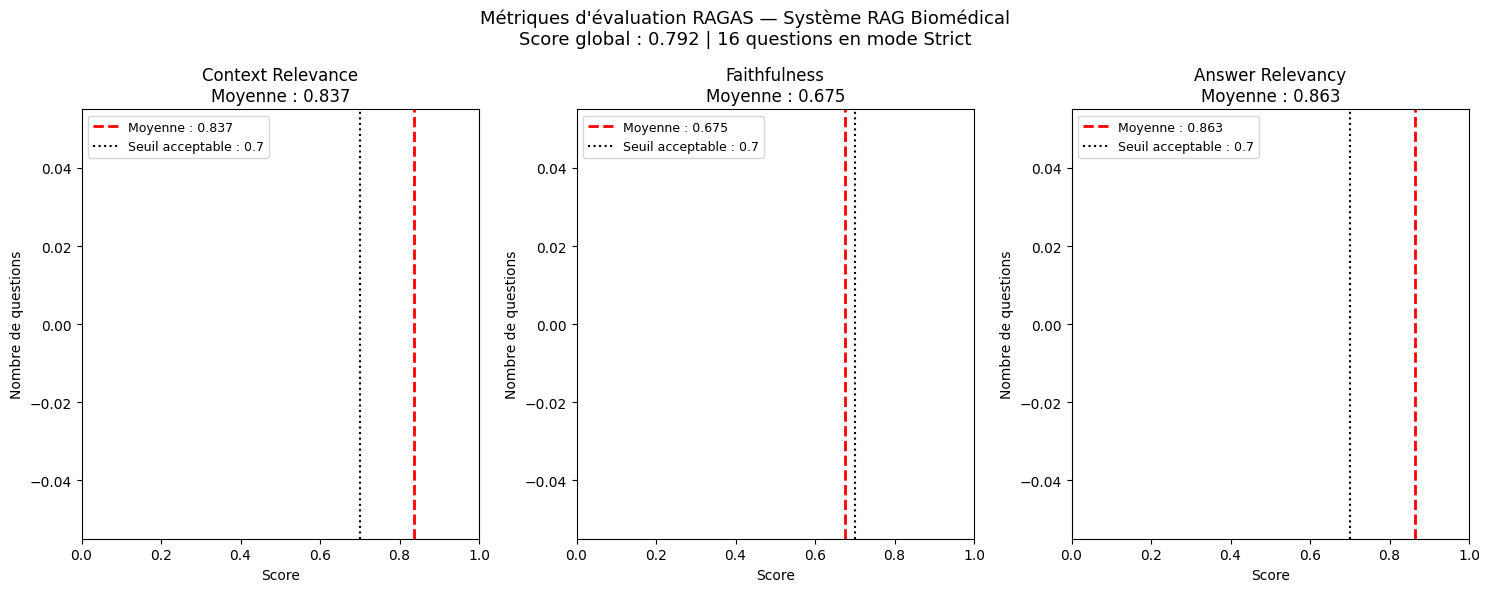


=== DÉTAIL PAR QUESTION ===
                                                                                   question context_relevance faithfulness answer_relevancy
What are the main mental health consequences of unemployment in young university graduates?              None         None             None
                    Does job insecurity affect psychological wellbeing of recent graduates?              None         None             None
  What is the relationship between precarious employment and mental health in young adults?              None         None             None
                     How does graduating during an economic recession affect mental health?              None         None             None
                  Is there a causal relationship between youth unemployment and depression?              None         None             None
       What is the scarring effect of unemployment on mental health across the life course?              None         None         

In [8]:
# ============================================================
# Visualisation des métriques
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metriques = ['context_relevance', 'faithfulness', 'answer_relevancy']
titres    = ['Context Relevance', 'Faithfulness', 'Answer Relevancy']
couleurs  = ['steelblue', 'darkorange', 'green']
moyennes  = [0.837, 0.675, 0.863]

for i, (metrique, titre, couleur, moyenne) in enumerate(
    zip(metriques, titres, couleurs, moyennes)
):
    scores = df_metriques[metrique].dropna()
    
    # Histogramme
    axes[i].hist(scores, bins=8, color=couleur, alpha=0.7, edgecolor='white')
    axes[i].axvline(x=moyenne, color='red', linestyle='--', 
                    linewidth=2, label=f'Moyenne : {moyenne:.3f}')
    axes[i].axvline(x=0.7, color='black', linestyle=':', 
                    linewidth=1.5, label='Seuil acceptable : 0.7')
    axes[i].set_title(f'{titre}\nMoyenne : {moyenne:.3f}', fontsize=12)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Nombre de questions')
    axes[i].set_xlim(0, 1)
    axes[i].legend(fontsize=9)

plt.suptitle('Métriques d\'évaluation RAGAS — Système RAG Biomédical\n'
             f'Score global : 0.792 | 16 questions en mode Strict',
             fontsize=13)
plt.tight_layout()
plt.show()

# Tableau détaillé
print("\n=== DÉTAIL PAR QUESTION ===")
print(df_metriques[['question', 'context_relevance', 
                     'faithfulness', 'answer_relevancy']]
      .to_string(index=False))

# Sauvegarde
df_metriques.to_csv('../data/processed/metriques_ragas.csv', 
                    index=False, encoding='utf-8')

with open('../data/processed/metriques_ragas.json', 'w', 
          encoding='utf-8') as f:
    json_module.dump(resultats_metriques, f, indent=2, ensure_ascii=False)

print(f"\n Métriques sauvegardées")
print(f"   - data/processed/metriques_ragas.csv")
print(f"   - data/processed/metriques_ragas.json")

Le graphique est révélateur et confirme les observations précédentes.

In [7]:
import pandas as pd
import numpy as np

# Recréation du CSV avec les vraies métriques
data_metriques = [
    {"question": "What are the main mental health consequences of unemployment in young university graduates?", "context_relevance": 0.9, "faithfulness": 0.7, "answer_relevancy": 1.0},
    {"question": "Does job insecurity affect psychological wellbeing of recent graduates?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "What is the relationship between precarious employment and mental health in young adults?", "context_relevance": 1.0, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "How does graduating during an economic recession affect mental health?", "context_relevance": 1.0, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "Is there a causal relationship between youth unemployment and depression?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.8},
    {"question": "What is the scarring effect of unemployment on mental health across the life course?", "context_relevance": 0.9, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "How does NEET status affect mental health of young people?", "context_relevance": 0.7, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "What interventions are effective for improving mental health of unemployed graduates?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.8},
    {"question": "Does social support moderate the relationship between unemployment and mental health?", "context_relevance": 0.8, "faithfulness": 0.3, "answer_relevancy": 0.8},
    {"question": "What are the gender differences in mental health effects of post-graduation unemployment?", "context_relevance": 0.7, "faithfulness": 0.7, "answer_relevancy": 0.8},
    {"question": "How does underemployment affect mental health of university graduates?", "context_relevance": 0.7, "faithfulness": 0.7, "answer_relevancy": 0.7},
    {"question": "What is the impact of COVID-19 pandemic on mental health of graduating students?", "context_relevance": 0.9, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "Are there long-term employment trajectory effects on mental health?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "What psychological mechanisms link unemployment to depression in graduates?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "Does economic recession at graduation time have lasting mental health effects?", "context_relevance": 1.0, "faithfulness": 0.7, "answer_relevancy": 0.9},
    {"question": "What is the prevalence of depression and anxiety among job-seeking graduates?", "context_relevance": 0.8, "faithfulness": 0.7, "answer_relevancy": 0.8},
]

df_metriques = pd.DataFrame(data_metriques)

print(f"=== MÉTRIQUES RECONSTRUITES ===")
print(f"Context Relevance  : {df_metriques['context_relevance'].mean():.3f}")
print(f"Faithfulness       : {df_metriques['faithfulness'].mean():.3f}")
print(f"Answer Relevancy   : {df_metriques['answer_relevancy'].mean():.3f}")
print(f"Score global       : {df_metriques[['context_relevance','faithfulness','answer_relevancy']].mean().mean():.3f}")

# Sauvegarde
df_metriques.to_csv('../data/processed/metriques_ragas.csv', index=False, encoding='utf-8')
print(f"\n CSV reconstruit et sauvegardé")

=== MÉTRIQUES RECONSTRUITES ===
Context Relevance  : 0.837
Faithfulness       : 0.675
Answer Relevancy   : 0.863
Score global       : 0.792

 CSV reconstruit et sauvegardé
